In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal
import matplotlib.patches as mpatches
import seaborn as sns

In [30]:
# Set plotting style
plt.rcParams.update({
    "grid.linewidth":   0.5,
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"
PALETTE = [BLUE, TEAL, AMBER, CORAL, PURPLE, GRAY,
           "#639922","#BA7517","#185FA5","#3B6D11"]

In [31]:
#file_path = r""
df = pd.read_csv("dataset_mood_smartphone.csv")
df.head()

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.0
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.0
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.0
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.0
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.0


In [32]:
# Add date and hour only columns 
df["time"] = pd.to_datetime(df["time"])
df["date"] = df["time"].dt.date
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["time"].dt.hour
df.head()

,Unnamed: 0,id,time,variable,value,date,hour
0,1,AS14.01,2014-02-26 13:00:00,mood,6.0,2014-02-26,13
1,2,AS14.01,2014-02-26 15:00:00,mood,6.0,2014-02-26,15
2,3,AS14.01,2014-02-26 18:00:00,mood,6.0,2014-02-26,18
3,4,AS14.01,2014-02-26 21:00:00,mood,7.0,2014-02-26,21
4,5,AS14.01,2014-02-27 09:00:00,mood,6.0,2014-02-27,9


## Exploratory Data Analysis

In [33]:
print("Number of observations x Number of columns:", df.shape)
print("Earliest timestamp:", df['time'].min())
print("Latest timestamp", df['time'].max())
print("Unique users:", df['id'].nunique())
print("Unique variables:", df['variable'].nunique())
print("Total missing values (in value column):", df['value'].isnull().sum())

Number of observations x Number of columns: (376912, 7)
Earliest timestamp: 2014-02-17 07:00:52.197000
Latest timestamp 2014-06-09 00:00:00
Unique users: 27
Unique variables: 19
Total missing values (in value column): 202


In [34]:
grouped = df.groupby("variable")["value"]
# Total count and missing count per variable
total_per_variable = grouped.count()
missing_per_variable = grouped.size() - grouped.count()
missing_pct = (missing_per_variable / (missing_per_variable + total_per_variable)) * 100

stats = grouped.describe().rename(columns={"50%": "median"})
stats["missing"] = missing_per_variable
stats["missing %"] = missing_pct.round(1).fillna(100.0)
# Add variable type based on unique values and specific variable name
stats["type"] = [
    "binary" if df.loc[df["variable"] == var, "value"].nunique(dropna=True) <= 2
    else "ordinal" if var == "mood" else "continuous"
    for var in stats.index
]
stats

,count,mean,std,min,25%,median,75%,max,missing,missing %,type
variable,,,,,,,,,,,
activity,22965.0,0.115958,0.186946,0.000,0.00000,0.021739,0.158333,1.000,0,0.0,continuous
appCat.builtin,91288.0,18.538262,415.989243,-82798.871,2.02000,4.038000,9.922000,33960.246,0,0.0,continuous
appCat.communication,74276.0,43.343792,128.912750,0.006,5.21800,16.225500,45.475750,9830.777,0,0.0,continuous
appCat.entertainment,27125.0,37.576480,262.960476,-0.011,1.33400,3.391000,14.922000,32148.677,0,0.0,continuous
appCat.finance,939.0,21.755251,39.218361,0.131,4.07200,8.026000,20.155000,355.513,0,0.0,continuous
appCat.game,813.0,128.391615,327.145246,1.003,14.14800,43.168000,123.625000,5491.793,0,0.0,continuous
appCat.office,5642.0,22.578892,449.601382,0.003,2.00400,3.106000,8.043750,32708.818,0,0.0,continuous
appCat.other,7650.0,25.810839,112.781355,0.014,7.01900,10.028000,16.829250,3892.038,0,0.0,continuous
appCat.social,19145.0,72.401906,261.551846,0.094,9.03000,28.466000,75.372000,30000.906,0,0.0,continuous


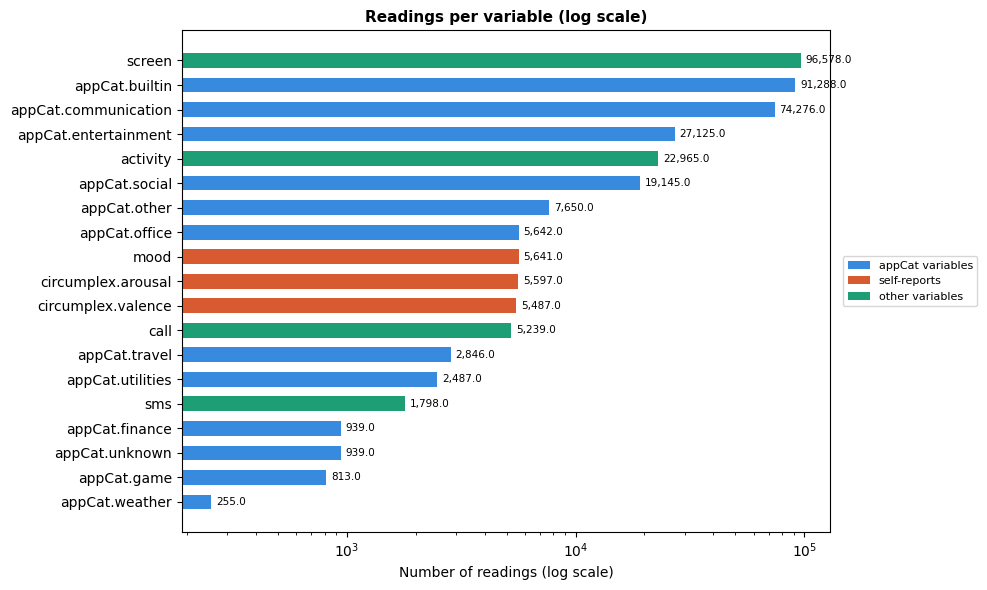

In [35]:
counts = stats["count"].sort_values(ascending=True)
colors_bar = [
    BLUE if "appCat" in v else
    CORAL if v in ("mood", "circumplex.arousal", "circumplex.valence") else
    TEAL
    for v in counts.index
]

plt.figure(figsize=(10, 6))
plt.barh(counts.index, counts.values, height=0.6, color=colors_bar)
plt.xscale("log")
plt.xlabel("Number of readings (log scale)")
plt.title("Readings per variable (log scale)")
plt.legend(
    handles=[
        mpatches.Patch(facecolor=BLUE, label="appCat variables"),
        mpatches.Patch(facecolor=CORAL, label="self-reports"),
        mpatches.Patch(facecolor=TEAL, label="other variables"),
    ],
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True,
)
for value, variable in zip(counts.values, counts.index):
    plt.text(value * 1.05, variable, f"{value:,}", va="center", fontsize=7.5)
plt.tight_layout()
plt.show()

# Sensor data (screen, appCat) is sampled far more than self-reports (mood, arousal). Maybe table is enough to show this
# Need to understand how to handle this when we will pivot the data to wide format and have missing values for self-reports.

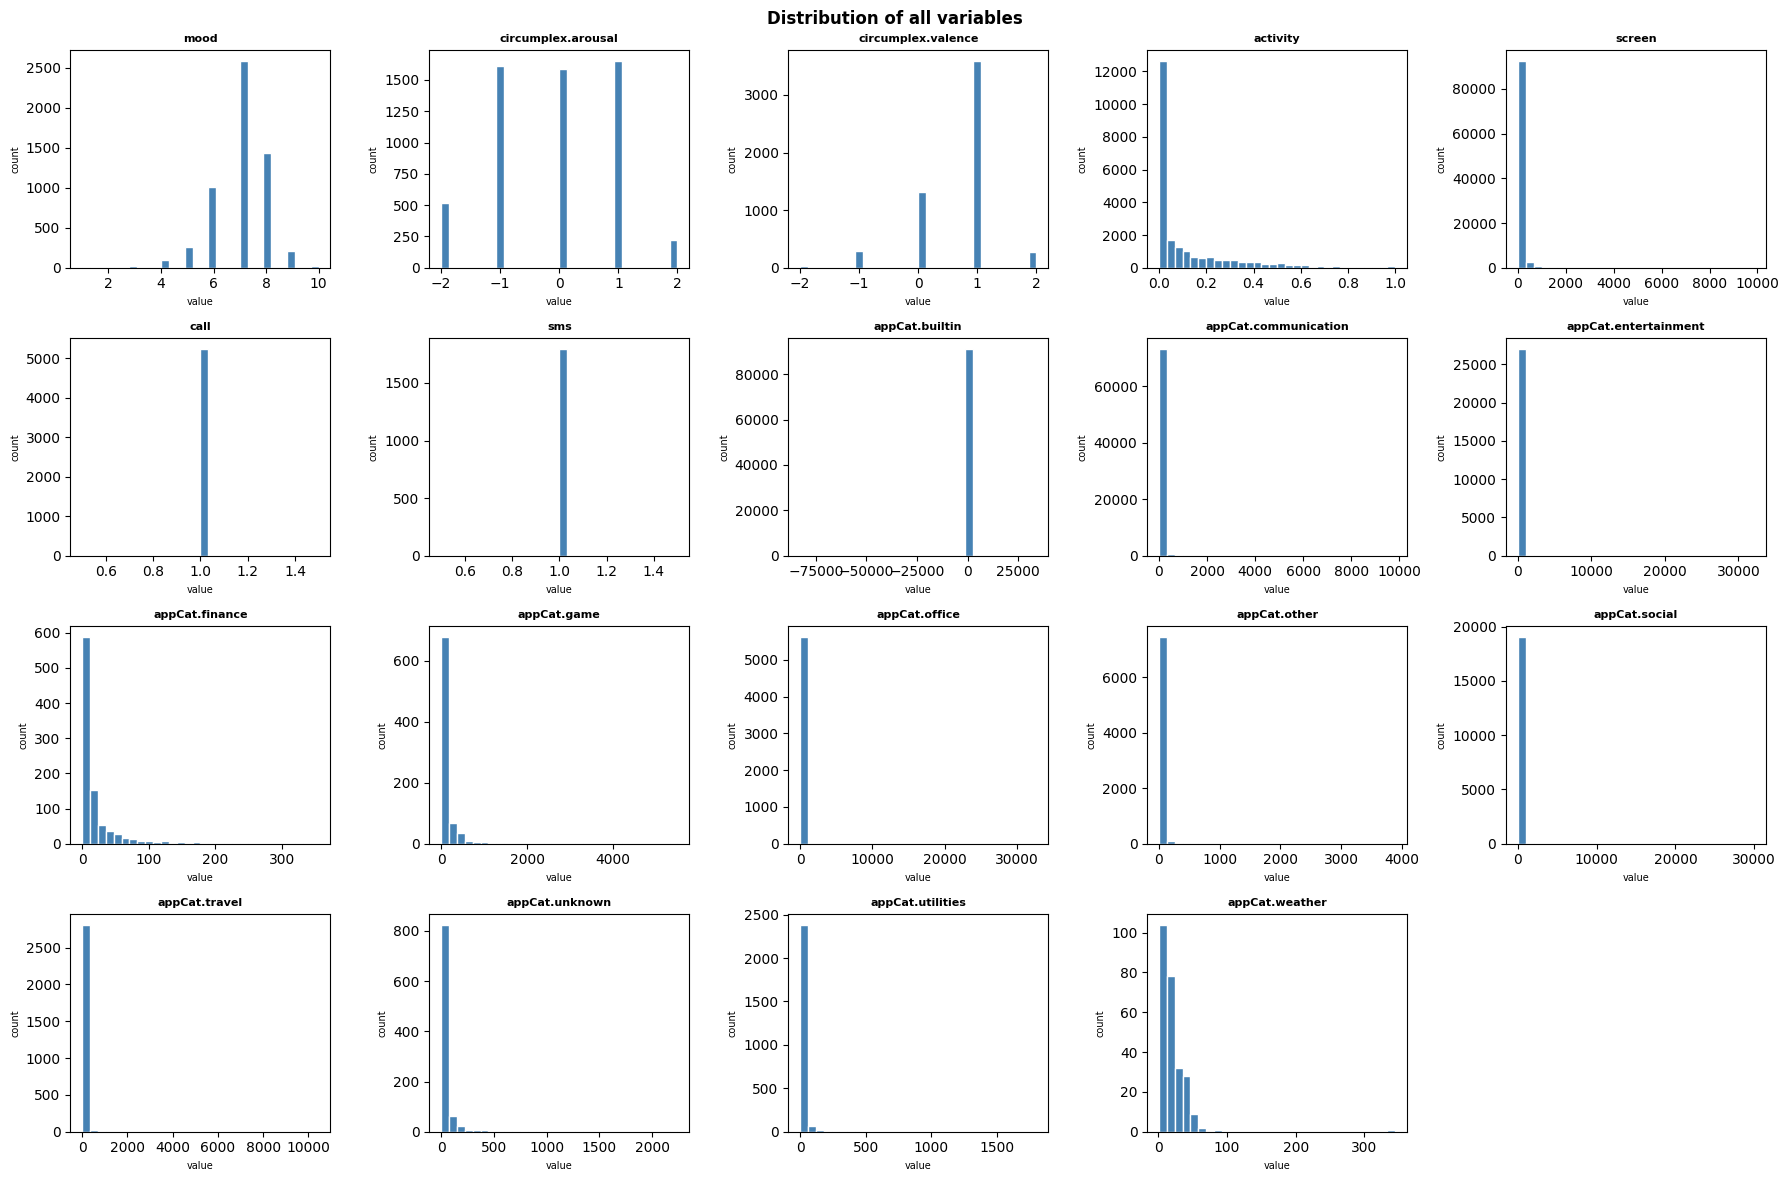

In [36]:
# Distribution of all variables (histograms)
variables = df["variable"].unique()
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
 
for ax, var in zip(axes.flatten(), variables):
    values = df[df["variable"] == var]["value"].dropna()
    ax.hist(values, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(var, fontsize=8)
    ax.set_xlabel("value", fontsize=7)
    ax.set_ylabel("count", fontsize=7)
 
# hide the last empty subplot
axes.flatten()[-1].set_visible(False)
 
plt.suptitle("Distribution of all variables", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


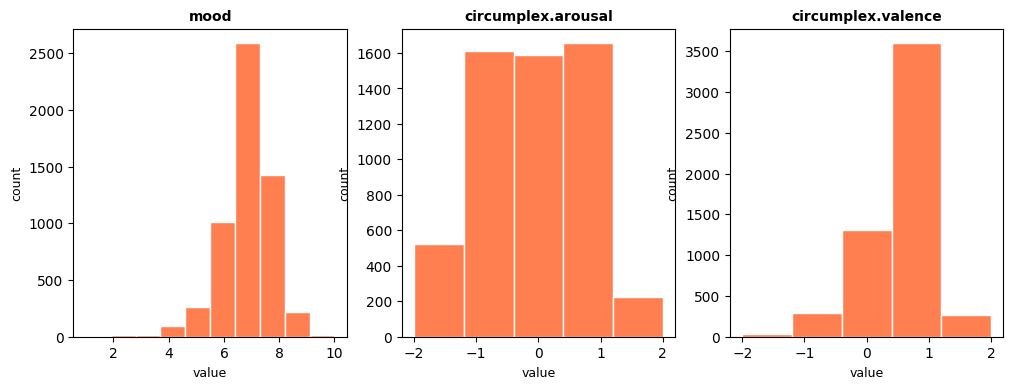

In [37]:
# Focus on mood variables
mood_vars = ["mood", "circumplex.arousal", "circumplex.valence"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4)) 
for ax, var in zip(axes, mood_vars):
    values = df[df["variable"] == var]["value"].dropna()
    if var == "mood":
        bins = np.arange(1, 11) - 0.5
        ax.hist(values, bins=10, color="coral", edgecolor="white")
    else:
        bins = np.arange(-2, 3) - 0.5
        ax.hist(values, bins=5, color="coral", edgecolor="white")
    ax.set_title(var, fontsize=10)
    ax.set_xlabel("value", fontsize=9)
    ax.set_ylabel("count", fontsize=9)

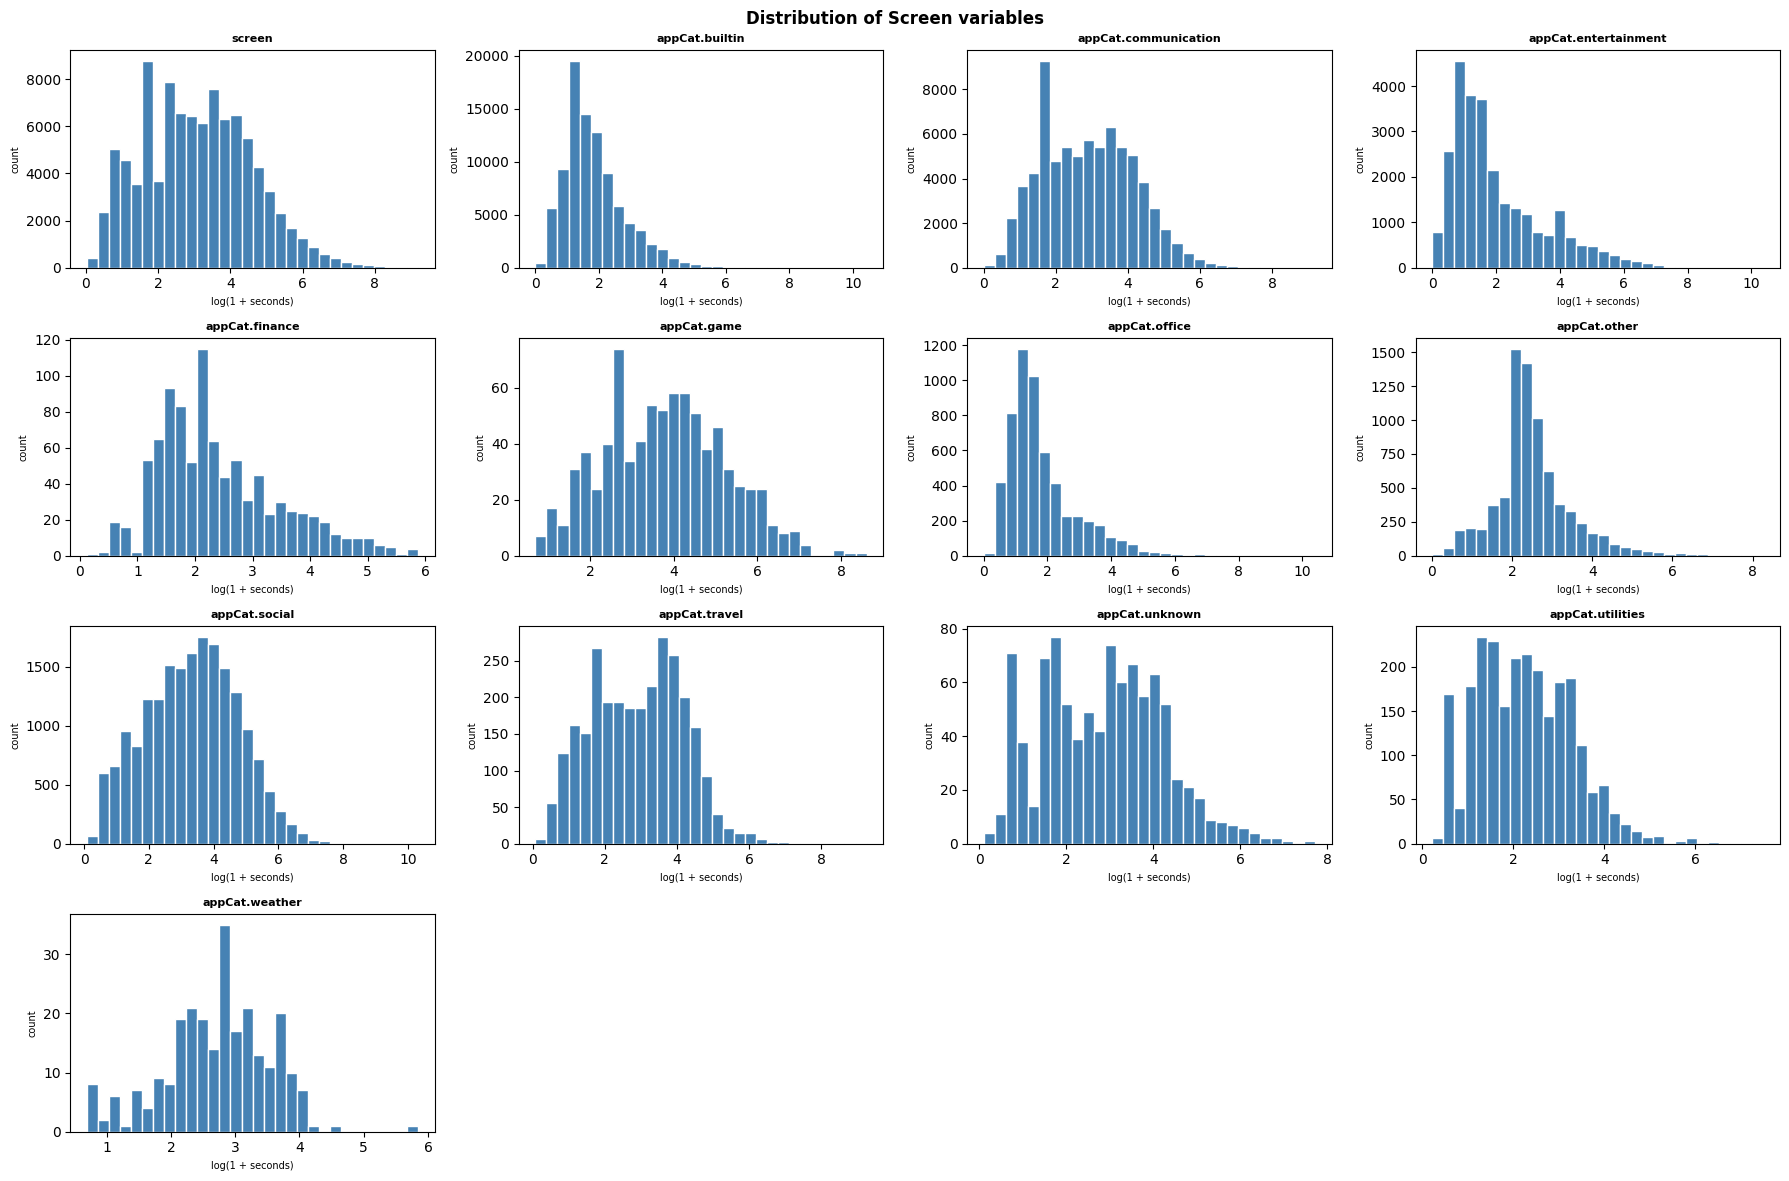

In [38]:
# Focus on screen and app category variables
# highly skewed distributions with many zeros, so we can log-transform the values
duration_vars = ["screen", "appCat.builtin", "appCat.communication",
                 "appCat.entertainment", "appCat.finance", "appCat.game",
                 "appCat.office", "appCat.other", "appCat.social",
                 "appCat.travel", "appCat.unknown", "appCat.utilities",
                 "appCat.weather"]
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
 
for ax, var in zip(axes.flatten(), duration_vars):
    if var in duration_vars:
        values = df[df["variable"] == var]["value"].dropna()
        values = np.log1p(values.clip(lower=0)) # to avoid log of negative values + log(0) issues
        ax.set_xlabel("log(1 + seconds)", fontsize=7)
        ax.hist(values, bins=30, color="steelblue", edgecolor="white")
        ax.set_title(var, fontsize=8)
        ax.set_ylabel("count", fontsize=7)

axes.flatten()[-1].set_visible(False)
axes.flatten()[-2].set_visible(False)
axes.flatten()[-3].set_visible(False)
 
plt.suptitle("Distribution of Screen variables", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

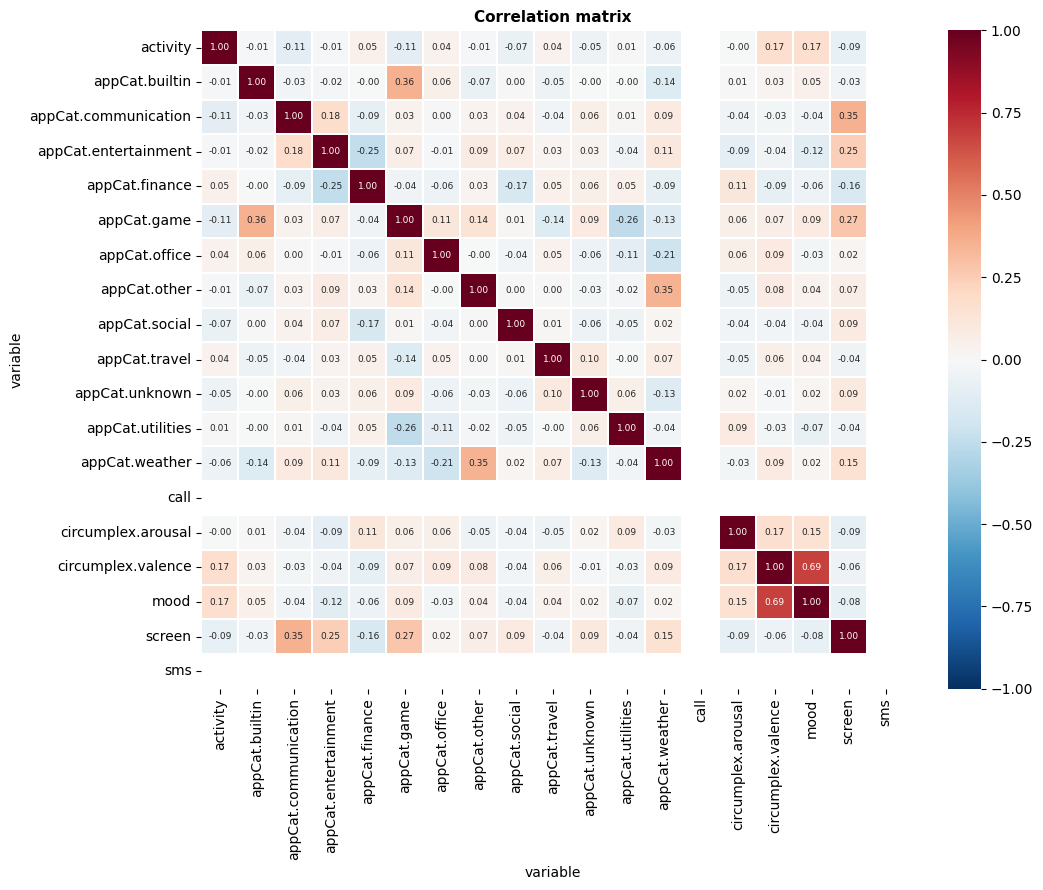

In [39]:
# correlation matrix for numeric variables in long-format data (**Check**)
correlation_data = (
    df.groupby(["id", "date", "variable"])["value"]
      .mean() 
      .unstack("variable")
)

correlation_data = correlation_data.dropna(axis=1, how="all")
correlation_matrix = correlation_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={"size": 6.5},
    ax=ax,
)
ax.set_title("Correlation matrix", fontweight="bold")
plt.tight_layout()
plt.show()

# high correlation between mood and valance

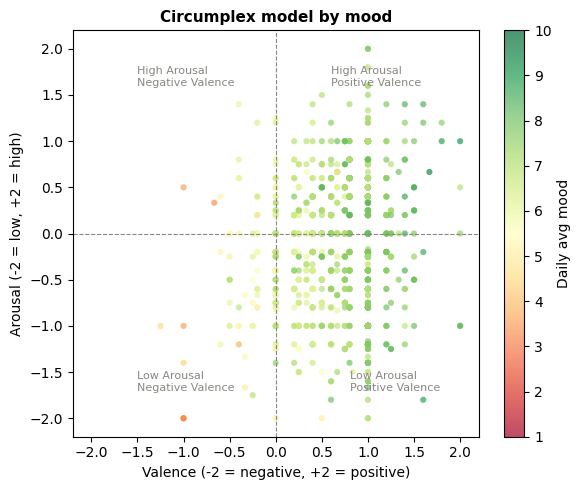

In [40]:
# Check valence and arousal correlation with mood 
circ = (df[df["variable"].isin(["circumplex.arousal","circumplex.valence","mood"])]
        .groupby(["id","date","variable"])["value"].mean()
        .unstack("variable").reset_index().dropna())
 
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(circ["circumplex.valence"], circ["circumplex.arousal"],
                c=circ["mood"], cmap="RdYlGn", vmin=1, vmax=10,
                alpha=0.7, linewidths=0, s = 20)
plt.colorbar(sc, ax=ax, label="Daily avg mood")
plt.axhline(0, color=GRAY, lw=0.8, ls="--")
plt.axvline(0, color=GRAY, lw=0.8, ls="--")
plt.ylim(-2.2, 2.2)
plt.xlim(-2.2, 2.2)
plt.xlabel("Valence (-2 = negative, +2 = positive)")
plt.ylabel("Arousal (-2 = low, +2 = high)")
plt.title("Circumplex model by mood")
# Quadrant labels
for x, y, lbl in [(.6, 1.6, "High Arousal\nPositive Valence"), (.8, -1.7, "Low Arousal\nPositive Valence"),
                   (-1.5, 1.6, "High Arousal\nNegative Valence"), (-1.5, -1.7, "Low Arousal\nNegative Valence")]:
    plt.text(x, y, lbl, fontsize=8, color=GRAY)
plt.tight_layout()
plt.show()

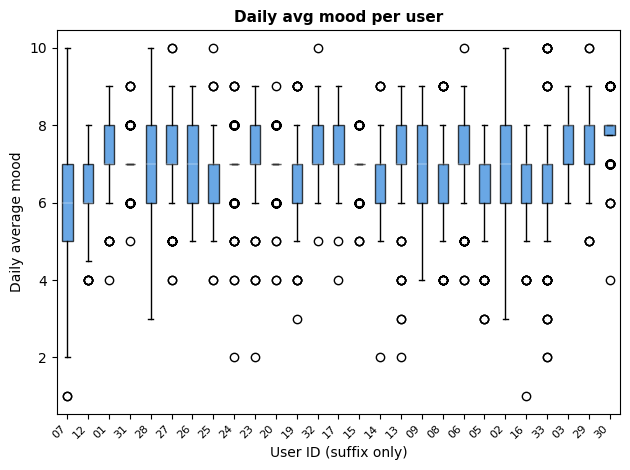

In [41]:
## Other plots for exploration (e.g., usage patterns by hour of day, mood over time, etc.)
# Distribution of mood ratings per user
mood = df[df["variable"] == "mood"][["id", "time", "value"]].copy()
# daily averages per user
daily_mood = mood.groupby(["id", "time"])["value"].mean().reset_index()
user_order = (daily_mood.groupby("id")["value"]
              .median().sort_values().index.tolist())
data_per_user = [daily_mood[daily_mood["id"] == u]["value"].values
                 for u in user_order]
bp = plt.boxplot(data_per_user, vert=True, patch_artist=True, medianprops=dict(color="white", lw=0.3))
for patch in bp["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.75)
ax = plt.gca()
ax.set_xticks(range(1, len(user_order) + 1))
ax.set_xticklabels([u.replace("AS14.", "") for u in user_order], rotation=45, ha="right", fontsize=8)
plt.xlabel("User ID (suffix only)")
plt.ylabel("Daily average mood")
plt.title("Daily avg mood per user")
plt.tight_layout()
plt.show()


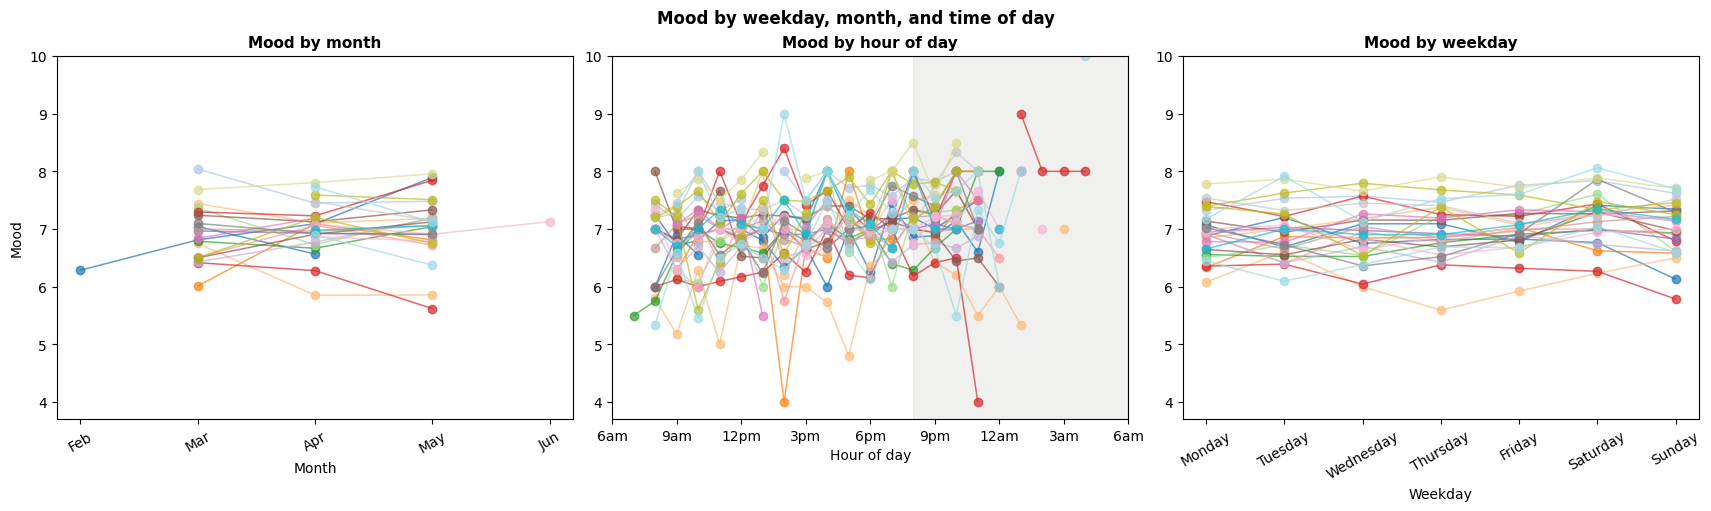

In [42]:
# Check mood patterns by weekday, month, and hour of day (line plots)
all_users = sorted(df.loc[df["variable"] == "mood", "id"].dropna().unique())
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = sorted(df.loc[df["variable"] == "mood", "time"].dt.month.dropna().unique())
month_labels = [pd.Timestamp(month=month, day=1, year=2000).strftime("%b") for month in month_order]
hour_order = list(range(6, 30))
user_colors = dict(zip(all_users, plt.cm.tab20(np.linspace(0, 1, max(len(all_users), 1)))))
 
fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
 
for uid in all_users:
    user_mood = df[(df["id"] == uid) & (df["variable"] == "mood")].copy()
    user_mood["weekday"] = user_mood["time"].dt.day_name()
    user_mood["month"] = user_mood["time"].dt.month
    user_mood["hour"] = user_mood["time"].dt.hour
 
    weekday_mood = user_mood.groupby("weekday")["value"].mean().reindex(weekday_order)
    month_mood = user_mood.groupby("month")["value"].mean().reindex(month_order)
    hour_mood = user_mood.groupby("hour")["value"].mean().reindex(range(24))
    hour_mood = pd.concat([hour_mood.loc[6:23], hour_mood.loc[0:5]])
 
    axes[0].plot(month_order, month_mood.values, "-o", color=user_colors[uid], lw=1.1, alpha=0.7)
    axes[1].plot(hour_order, hour_mood.values, "-o", color=user_colors[uid], lw=1.1, alpha=0.7)
    axes[2].plot(weekday_order, weekday_mood.values, "-o", color=user_colors[uid], lw=1.1, alpha=0.7)
 
axes[0].set_title("Mood by month")
axes[1].set_title("Mood by hour of day")
axes[2].set_title("Mood by weekday")
 
axes[0].set_ylabel("Mood")
axes[0].set_ylim(3.7, 10)
axes[1].set_ylim(3.7, 10)
axes[2].set_ylim(3.7, 10)
 

axes[0].set_xticks(month_order)
axes[0].set_xticklabels(month_labels, rotation=30)
axes[1].set_xticks([6, 9, 12, 15, 18, 21, 24, 27, 30])
axes[1].set_xticklabels(["6am", "9am", "12pm", "3pm", "6pm", "9pm", "12am", "3am", "6am"])
axes[1].axvspan(20, 30, color=GRAY, alpha=0.12)
axes[1].set_xlim(6, 30)
axes[2].tick_params(axis="x", rotation=30)

axes[0].set_xlabel("Month")
axes[1].set_xlabel("Hour of day")
axes[2].set_xlabel("Weekday")
 
fig.suptitle("Mood by weekday, month, and time of day", fontweight="bold")
plt.show()

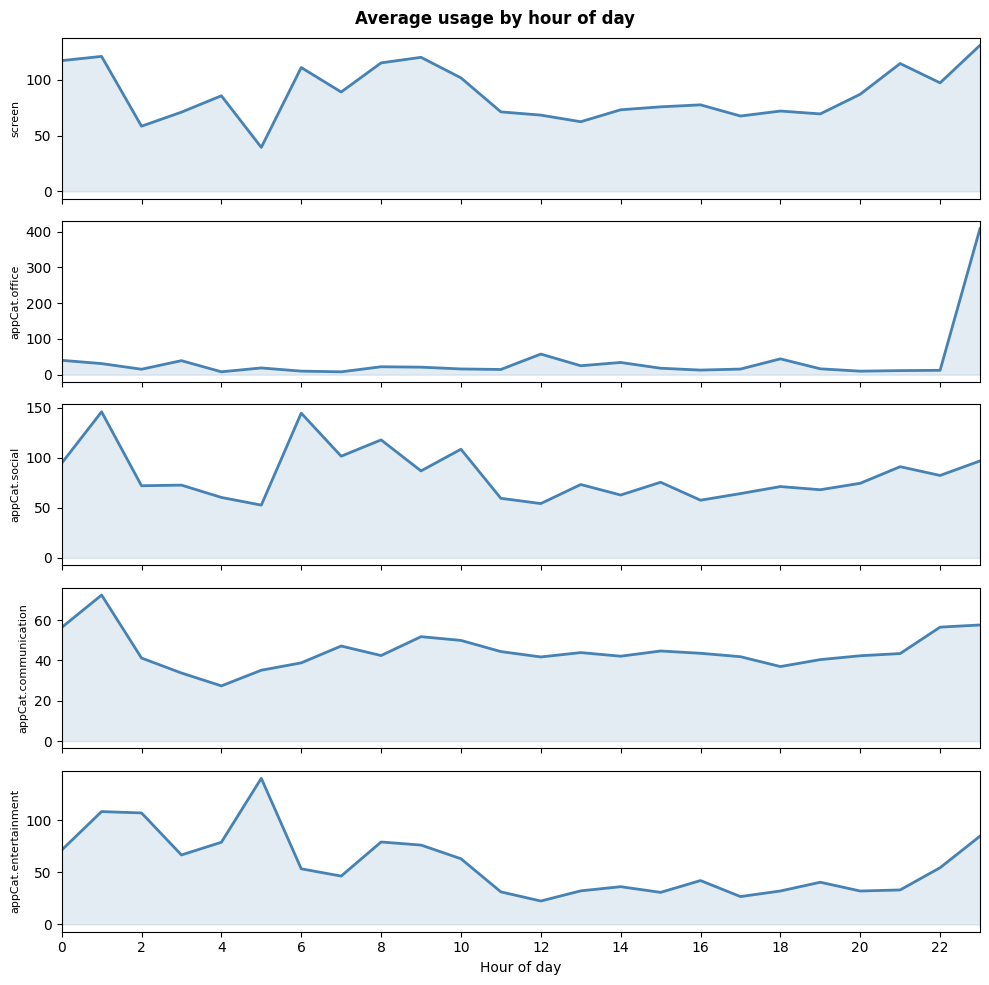

In [43]:
usage_vars = ["screen", "appCat.office", "appCat.social",
                "appCat.communication", "appCat.entertainment"]
 
fig, axes = plt.subplots(len(usage_vars), 1, figsize=(10, 10), sharex=True)
 
for ax, var in zip(axes, usage_vars):
    hourly = (
        df[df["variable"] == var]
        .groupby(["date", "hour"])["value"]
        .mean()
        .groupby("hour")
        .mean()
        .reindex(range(24))
    )
    ax.plot(hourly.index, hourly.values, color="steelblue", lw=2)
    ax.fill_between(hourly.index, hourly.values, alpha=0.15, color="steelblue")
    ax.set_ylabel(var, fontsize=8)
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 2))
 
axes[-1].set_xlabel("Hour of day")
fig.suptitle("Average usage by hour of day", fontweight="bold")
plt.tight_layout()

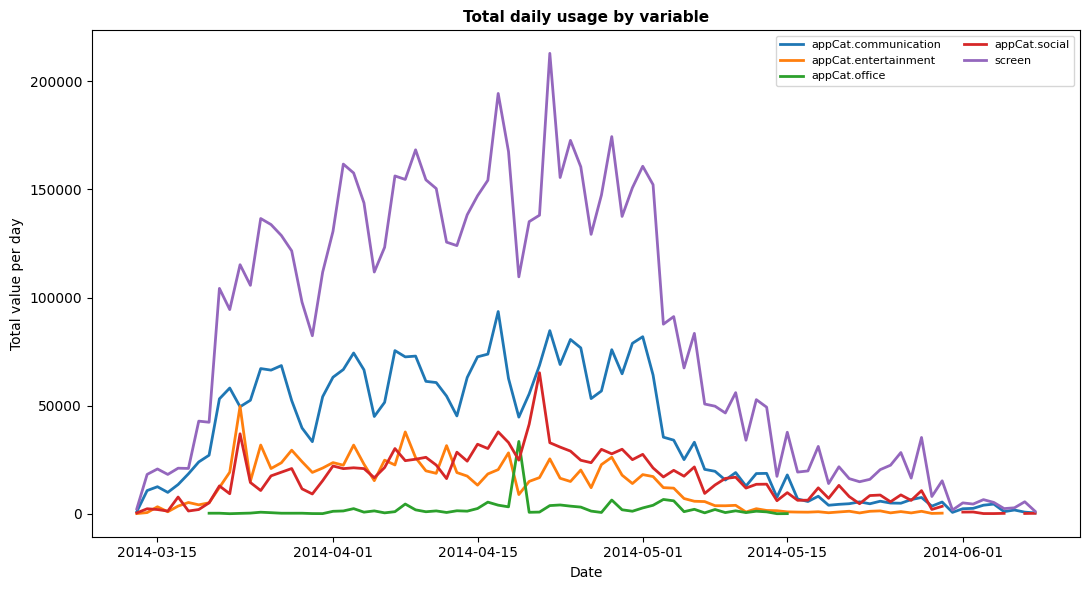

In [44]:
# Total daily usage per variable
daily_usage = (
    df[df["variable"].isin(usage_vars)]
    .groupby(["date", "variable"])["value"]
    .sum()
    .unstack("variable")
)

plt.figure(figsize=(11, 6))
for col in daily_usage.columns:
    plt.plot(daily_usage.index, daily_usage[col], linewidth=2, label=col)

plt.title("Total daily usage by variable", fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total value per day")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Notes

- data is between 02/2014 until 06/2014, but only for 2 people feb and june are included
- appCat.builtin and entertainment have min negative values: remove or clip?
- usage times have extreme outliers (e.g. screen max is approx 2.7 hours, social is 8h and office is 9h)
- call and sms mark events
- mood mean = 7.0, std = 1.0
- circumplex.valence mean = 0.69 (positive), arousal mean = -0.10 (calm)
 

Part 1B: Data Cleaning

In [45]:
duration_vars = ["screen", "appCat.builtin", "appCat.communication",
                 "appCat.entertainment", "appCat.finance", "appCat.game",
                 "appCat.office", "appCat.other", "appCat.social",
                 "appCat.travel", "appCat.unknown", "appCat.utilities",
                 "appCat.weather"]

# check for negative values in duration variables (should not be possible)

negative_counts = df[df["variable"].isin(duration_vars) & (df["value"] < 0)].groupby("variable")["value"].count()
print(negative_counts)

variable
appCat.builtin          3
appCat.entertainment    1
Name: value, dtype: int64


In [46]:
# cleaning the data

# replacing negative values with NaN for the two impossible negative minmums
duration_vars = ["screen", "appCat.builtin", "appCat.communication",
                 "appCat.entertainment", "appCat.finance", "appCat.game",
                 "appCat.office", "appCat.other", "appCat.social",
                 "appCat.travel", "appCat.unknown", "appCat.utilities",
                 "appCat.weather"]

for var in duration_vars:
    df.loc[(df["variable"] == var) & (df["value"] < 0), "value"] = np.nan

# making sure time in seconds is in 1 day range

outlier_counts = df[df["variable"].isin(duration_vars) & (df["value"] > 24*3600)].groupby("variable")["value"].count()
print(outlier_counts)

# no impossible values above 24 hours, so I am keeping the rest of the data as is. Now to pivot to wide format.


Series([], Name: value, dtype: int64)


In [47]:
# grouping mood, arousal, valence
mood_data = df[df["variable"].isin(["mood", "circumplex.arousal", "circumplex.valence"])]
mood_pivot = mood_data.pivot_table(index=["id", "date"], columns="variable", values="value", aggfunc="mean").reset_index()
mood_pivot.head()

variable,id,date,circumplex.arousal,circumplex.valence,mood
0,AS14.01,2014-02-26,-0.25,0.750000,6.250000
1,AS14.01,2014-02-27,0.00,0.333333,6.333333
2,AS14.01,2014-03-21,0.20,0.200000,6.200000
3,AS14.01,2014-03-22,0.60,0.500000,6.400000
4,AS14.01,2014-03-23,0.20,0.800000,6.800000


In [48]:
# grouping duration variables
duration_data = df[df["variable"].isin(duration_vars)]
duration_pivot = duration_data.pivot_table(index=["id", "date"], columns="variable", values="value", aggfunc="sum").reset_index()
duration_pivot.head()

variable,id,date,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,screen
0,AS14.01,2014-03-20,248.979,2168.229,350.856,NaN,NaN,NaN,11.345,807.731,NaN,45.173,21.074,NaN,2275.944000
1,AS14.01,2014-03-21,3139.218,6280.890,1007.456,49.544,NaN,172.206,239.751,4508.500,915.445,NaN,598.754,NaN,17978.907000
2,AS14.01,2014-03-22,731.429,4962.918,93.324,21.076,NaN,NaN,98.143,439.632,37.305,NaN,117.621,NaN,6142.161000
3,AS14.01,2014-03-23,1286.246,5237.319,94.346,43.403,NaN,NaN,72.823,900.839,NaN,NaN,30.086,30.386,6773.832001
4,AS14.01,2014-03-24,866.956,9270.629,976.971,34.106,NaN,3.010,66.558,3223.626,419.805,NaN,178.732,NaN,15047.351001


In [49]:
# grouping calls and sms variables
calls_sms_data = df[df["variable"].isin(["call", "sms"])]
calls_sms_pivot = calls_sms_data.pivot_table(index=["id", "date"], columns="variable", values="value", aggfunc="max").reset_index()
calls_sms_pivot.head()

variable,id,date,call,sms
0,AS14.01,2014-02-17,1.0,NaN
1,AS14.01,2014-02-18,1.0,NaN
2,AS14.01,2014-02-19,1.0,1.0
3,AS14.01,2014-02-20,1.0,1.0
4,AS14.01,2014-02-21,NaN,1.0


In [50]:
# combining pivot tables into one wide-format table

df_wide = mood_pivot.merge(duration_pivot, on=["id", "date"], how="outer").merge(calls_sms_pivot, on=["id", "date"], how="outer")
print("Wide format shape:", df_wide.shape)
df_wide.head()

Wide format shape: (1971, 20)


variable,id,date,circumplex.arousal,circumplex.valence,mood,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,screen,call,sms
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


There are a lot of not available data points. In areas like valence, mood and arousal I will assume that these are genuinely missed days and that these points will have to be imputed. On the other hand, there are multiple NaNs in collumns such as finance or weather apps. For now I will replace these NaNs with 0s, as my assumption is that people did not use these apps on certain days, and that their use would've been tracked automatically.

In [51]:
# filling in apps usage NaNs with 0s, as assumption is that these were days when people did not use these apps, and that their use would've been tracked automatically. For mood, arousal and valence I will keep the NaNs for now, as I will impute them later.

for col in df_wide.columns:
    if col.startswith("appCat") or col == "screen" or col in ["call", "sms"]:
        df_wide[col] = df_wide[col].fillna(0)

df_wide.head()

variable,id,date,circumplex.arousal,circumplex.valence,mood,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,screen,call,sms
0,AS14.01,2014-02-17,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,AS14.01,2014-02-18,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,AS14.01,2014-02-19,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,AS14.01,2014-02-20,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,AS14.01,2014-02-21,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [52]:
# Imputation Method: Last Observation Carried Forward (LOCF) for mood, arousal, and valence

df_wide_LOCF = df_wide.copy()

for var in ["mood", "circumplex.arousal", "circumplex.valence"]:
    df_wide_LOCF[var] = df_wide.groupby("id")[var].ffill()

df_wide_LOCF.head()

# amount of NaNs before imputation for mood, arousal and valence
print("NaNs in mood before imputation:", df_wide["mood"].isna().sum())
print("NaNs in arousal before imputation:", df_wide["circumplex.arousal"].isna().sum())
print("NaNs in valence before imputation:", df_wide["circumplex.valence"].isna().sum())

# amount of NaNs left after LOCF imputation for mood, arousal and valence
print("NaNs in mood after LOCF:", df_wide_LOCF["mood"].isna().sum())
print("NaNs in arousal after LOCF:", df_wide_LOCF["circumplex.arousal"].isna().sum())
print("NaNs in valence after LOCF:", df_wide_LOCF["circumplex.valence"].isna().sum())

NaNs in mood before imputation: 703
NaNs in arousal before imputation: 703
NaNs in valence before imputation: 705
NaNs in mood after LOCF: 642
NaNs in arousal after LOCF: 642
NaNs in valence after LOCF: 642


LOCF is a common method we used in our bachelor when dealing with clinical data, so I kind of chose it because I am a familiar with it (and it's super easy to implement). I think it also makes sense here, if a participant forgot to self report, then taking the value from their last known report would be fair, albeit a generalizaition of their mood.

Sources:

https://medium.com/@aaabulkhair/data-imputation-demystified-time-series-data-69bc9c798cb7 (not clear scientific journal)

https://www.lexjansen.com/nesug/nesug09/po/PO12.pdf

Preliminary Discussion:

A possible problem that comes with LOCF is that it may be introducing bias in cases where data is not stationary. Here I am assuming that yesterdays mood value can be assumed for today, and although I don't think it's an invalid assumption, I would say it introduces bias. Seems like not that many NaNs were imputed, but that's largely due to the first rows of the dataset being empty. The method cannot impute retroactivcely. And if we did decide to backfill those, that would be a lot of made up datapoints.

In [53]:
# Imputation Method: Rolling Mean with a window of 3 days for mood, arousal, and valence (alternative to LOCF)

df_wide_rolling = df_wide.copy()

for var in ["mood", "circumplex.arousal", "circumplex.valence"]:
    rolling_mean = df_wide.groupby("id")[var].rolling(window=3, min_periods=1).mean(). reset_index(level=0, drop=True)
    df_wide_rolling[var] = df_wide[var].fillna(rolling_mean)

# amount of NaNs left before rolling mean imputation for mood, arousal and valence
print("NaNs in mood before rolling mean:", df_wide["mood"].isna().sum())
print("NaNs in arousal before rolling mean:", df_wide["circumplex.arousal"].isna().sum())
print("NaNs in valence before rolling mean:", df_wide["circumplex.valence"].isna().sum())

# amount of NaNs left after rolling mean imputation for mood, arousal and valence
print("NaNs in mood after rolling mean:", df_wide_rolling["mood"].isna().sum())
print("NaNs in arousal after rolling mean:", df_wide_rolling["circumplex.arousal"].isna().sum())
print("NaNs in valence after rolling mean:", df_wide_rolling["circumplex.valence"].isna().sum())

NaNs in mood before rolling mean: 703
NaNs in arousal before rolling mean: 703
NaNs in valence before rolling mean: 705
NaNs in mood after rolling mean: 667
NaNs in arousal after rolling mean: 667
NaNs in valence after rolling mean: 667


Clearly this method did not impute as many data points as the previously used LOCF method. If I enlarge the time window, then more data points are imputed but I thought that 3 days was a reasonable amount (although I am struggling to find a source to support mt decision making here). From these results, I think the LOCF method makes more sense to me and is more effective here. It manages to impute more data points, and is based only off the emotion of the previous day not off of three days prior. Logically I think the argument for using it in this context is more sound than then rolling mean.

In [ ]:
# removing NaNs at the start of the dataset for each user
df_wide_LOCF_cleaned = df_wide_LOCF.copy()
df_wide_LOCF_cleaned = df_wide_LOCF_cleaned.dropna(subset=["mood", "circumplex.arousal", "circumplex.valence"], how="any")

#head
df_wide_LOCF_cleaned.head()

variable,date,circumplex.arousal,circumplex.valence,mood,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,screen,call,sms
count,1329,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000
mean,2014-04-15 03:42:07.313769728,-0.103950,0.679533,6.990231,1332.885112,2417.807233,765.430526,15.371092,78.542049,95.854106,148.175655,1042.669224,97.836192,32.140619,34.671783,3.866006,5466.393952,0.584650,0.334086
min,2014-02-26 00:00:00,-2.000000,-1.250000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2014-04-02 00:00:00,-0.600000,0.400000,6.600000,146.259000,464.504000,0.000000,0.000000,0.000000,0.000000,29.229000,0.000000,0.000000,0.000000,0.000000,0.000000,1554.525000,0.000000,0.000000
50%,2014-04-16 00:00:00,0.000000,0.800000,7.000000,625.437000,1778.979000,159.756000,0.000000,0.000000,0.000000,55.459000,333.256000,0.000000,0.000000,0.000000,0.000000,4475.892000,1.000000,0.000000
75%,2014-04-28 00:00:00,0.333333,1.000000,7.500000,1443.436000,3506.883000,944.294000,0.000000,0.000000,0.000000,113.335000,1464.611000,54.423000,0.000000,7.954000,0.000000,8079.531999,1.000000,1.000000
max,2014-06-08 00:00:00,2.000000,2.000000,9.333333,40323.877000,20718.749000,35937.645000,1321.104000,12996.495000,33283.021000,4335.307000,30073.421000,10548.116000,2821.547000,2257.626000,366.937000,36204.105001,1.000000,1.000000
std,NaN,0.663679,0.437905,0.744950,2903.831474,2480.631998,1640.630545,70.922408,484.406821,986.444901,368.433679,1815.776375,432.932150,155.366232,142.535543,20.009293,4808.873818,0.492968,0.471847


In [55]:
df_wide_LOCF_cleaned.describe()

variable,date,circumplex.arousal,circumplex.valence,mood,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,screen,call,sms
count,1329,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000,1329.000000
mean,2014-04-15 03:42:07.313769728,-0.103950,0.679533,6.990231,1332.885112,2417.807233,765.430526,15.371092,78.542049,95.854106,148.175655,1042.669224,97.836192,32.140619,34.671783,3.866006,5466.393952,0.584650,0.334086
min,2014-02-26 00:00:00,-2.000000,-1.250000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2014-04-02 00:00:00,-0.600000,0.400000,6.600000,146.259000,464.504000,0.000000,0.000000,0.000000,0.000000,29.229000,0.000000,0.000000,0.000000,0.000000,0.000000,1554.525000,0.000000,0.000000
50%,2014-04-16 00:00:00,0.000000,0.800000,7.000000,625.437000,1778.979000,159.756000,0.000000,0.000000,0.000000,55.459000,333.256000,0.000000,0.000000,0.000000,0.000000,4475.892000,1.000000,0.000000
75%,2014-04-28 00:00:00,0.333333,1.000000,7.500000,1443.436000,3506.883000,944.294000,0.000000,0.000000,0.000000,113.335000,1464.611000,54.423000,0.000000,7.954000,0.000000,8079.531999,1.000000,1.000000
max,2014-06-08 00:00:00,2.000000,2.000000,9.333333,40323.877000,20718.749000,35937.645000,1321.104000,12996.495000,33283.021000,4335.307000,30073.421000,10548.116000,2821.547000,2257.626000,366.937000,36204.105001,1.000000,1.000000
std,NaN,0.663679,0.437905,0.744950,2903.831474,2480.631998,1640.630545,70.922408,484.406821,986.444901,368.433679,1815.776375,432.932150,155.366232,142.535543,20.009293,4808.873818,0.492968,0.471847


## Notes:

- currently most cleaned version of data: df_wide_LOCF_cleaned

- could still remove extremities, I just focused on removing values that were actually impossible. But I wasn't sure how skeptical I could be with the values for certain app usages.

    - for example: the maximum time for using built in apps is almost 11 hours in a day. Logically I don't think someone is spending 11 hours in the calendar app. So I theorized doing a percentile cutoff of maybe the top 1% and bottom 1%. But he hasn't mentioned this in the lectures, and I feel I can't really justify it right now.

- data should be in correct format and ready for part 1C

- the assignment asks: "also consider what to do with prolonged periodsof missing data in a time series."
    - I just removed those initial 22 days of rows of NaNs, instead of imputing it. In my eyes, filling in that much data would be wrong. But that's more coming from my psychology background and I wonder whether he is expecting us to impute that data somehow, perhaps with a more advanced method? I'm not sure. Many decisions in this cleaning part that I think we can discuss together.

## 1C - FEATURE ENGINEERING

#### Adding the target value - next day mood

In [ ]:
df_wide_LOCF_cleaned['mood_next'] = (df_wide_LOCF_cleaned.groupby('id')['mood'].shift(-1))
display(df_wide_LOCF_cleaned.head())
df_wide_LOCF_cleaned.size

#now the last day for each subject has a nan target - should we drop it?

variable,id,date,circumplex.arousal,circumplex.valence,mood,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,...,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,screen,call,sms,mood_next
7,AS14.01,2014-02-26,-0.25,0.750000,6.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,6.333333
8,AS14.01,2014-02-27,0.00,0.333333,6.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.333333
9,AS14.01,2014-02-28,0.00,0.333333,6.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.333333
10,AS14.01,2014-03-01,0.00,0.333333,6.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.333333
11,AS14.01,2014-03-03,0.00,0.333333,6.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.333333


27909

In [66]:
# adding an additional lag variable - as they can be strong predictors for the next days mood

for lag in [1, 2, 3]:
    df[f'mood_lag{lag}'] = df.groupby('id')['mood'].shift(lag)
    df[f'activity_lag{lag}'] = df.groupby('id')['activity'].shift(lag)

KeyError: 'Column not found: mood'

In [ ]:
#interaction between call and sms and time 

In [65]:
#adding a weekday
df_wide_LOCF_cleaned['weekday'] = pd.to_datetime(df_wide_LOCF_cleaned['date']).dt.dayofweek

We should decide if we want to do a neural network or aggregate to create attributes. 